## DonchianChannel
A volatility indicator 

- H Band = Maximum of OLHC over the past N period
- L Band = Minimum of OLHC over the past N Period
- M Band = (H Band + L Band) / 2
- P Band = (Close - Low Band) / (High Band - Low Band)
- W Band = (High Band - Low Band) / N Period Moving Average

**Algorithm**
- Enter Short If:
    - P Band <= 0.5
    - Close < M Band
    - W Band > 0.8 #There is volatility
- Stay In Short:
    - P Band < Last P Band
    - W Band > Last W Band #Volatility is increasing
    - Close - L band < M Band - Close
    - But look to exit
- Exit Short If:
    - P Band > Last P Band
    - W Band < Last W Band #Volatility is reducing
    - Stop Loss at 5%
- Enter Long If:
    - P band >= 0.5
    - Close > M Band
    - W Band > 0.8 #There is volatility
- Stay In Long:
    - P Band > Last P Band
    - W Band > Last W Band #Volatility is increasing
    - H Band - Close < Close - M Band
- Exit Long If:
    - P Band < Last P Band
    - W Band < Last W Band #Volatility is reducing
    - Stop loss at 5%

- $10,000/Trade and No compounding

<p style="color:steelblue; font-weight: bold">Please run the last cell first before starting backtest</p>

In [1]:
from collections import deque
from dateutil.parser import parse
import pandas as pd
import numpy as np
import datetime
from datetime import timedelta
#Plotting
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
from ta.volatility import DonchianChannel
from ta.momentum import RSIIndicator

In [3]:
ticker = "MSTR"
data = pd.read_csv(f"../../../data/{ticker}.5MIN.csv")
data.set_index("timestamp",inplace=True)
data.index = pd.to_datetime(data.index)

In [4]:
df = data.copy()
donchain = DonchianChannel(high = df.high, low = df.low, close = df.close, window=12)
df['dc_hband'] = donchain.donchian_channel_hband()
df['dc_lband'] = donchain.donchian_channel_lband()
df['dc_mband'] = donchain.donchian_channel_mband()
df['dc_pband'] = donchain.donchian_channel_pband()
df['dc_wband'] = donchain.donchian_channel_wband()

In [5]:
# as_of_date = "2025-08-25"
as_of_date = "2025-11-20"

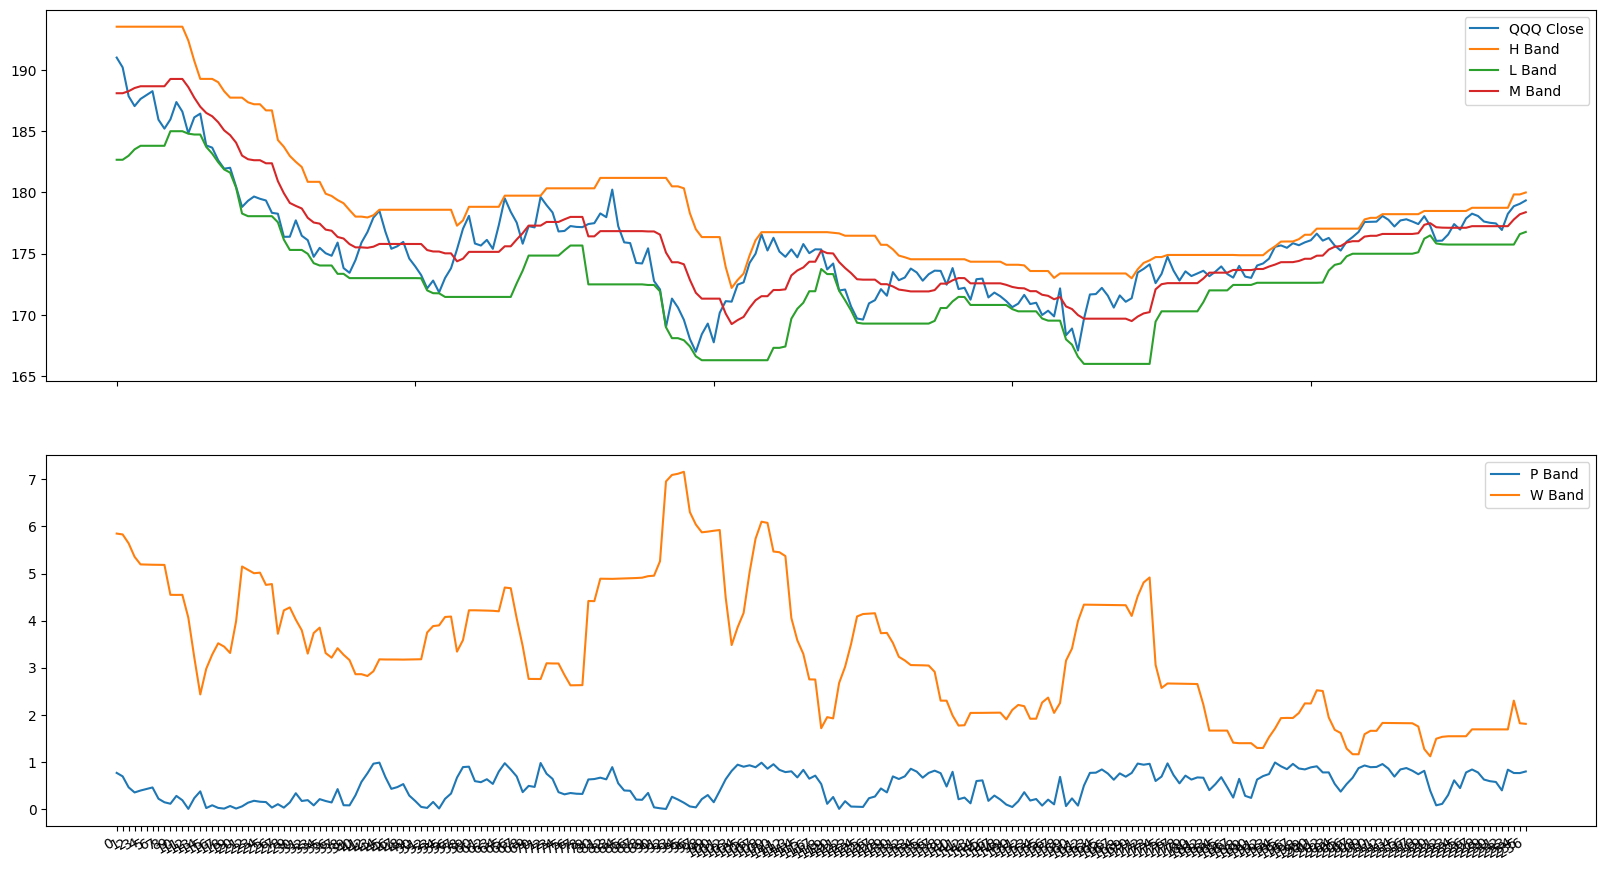

In [6]:
fig, axes = plt.subplots(2,1,figsize=(20,12))
axes[0].plot(range(len(df.close.loc[as_of_date:])), df.close.loc[as_of_date:].values, label = "QQQ Close")
axes[0].plot(range(len(df.close.loc[as_of_date:])), df.loc[as_of_date:, 'dc_hband'], label = "H Band")
axes[0].plot(range(len(df.close.loc[as_of_date:])), df.loc[as_of_date:, 'dc_lband'], label = "L Band")
axes[0].plot(range(len(df.close.loc[as_of_date:])), df.loc[as_of_date:, 'dc_mband'], label = "M Band")
axes[1].plot(range(len(df.close.loc[as_of_date:])), df.loc[as_of_date:, 'dc_pband'], label = "P Band")
axes[1].plot(range(len(df.close.loc[as_of_date:])), df.loc[as_of_date:, 'dc_wband'], label = "W Band")
axes[1].set_xticks(range(len(df.close.loc[as_of_date:])))
# axes[1].set_xticklabels(df.close.loc[as_of_date:].index)
fig.autofmt_xdate() # automatically formats the x-axis labels
axes[0].legend()
axes[1].legend()
plt.show()

## Run Backtest

In [9]:
df = donchain4(7,  data)

## Plot the last three days

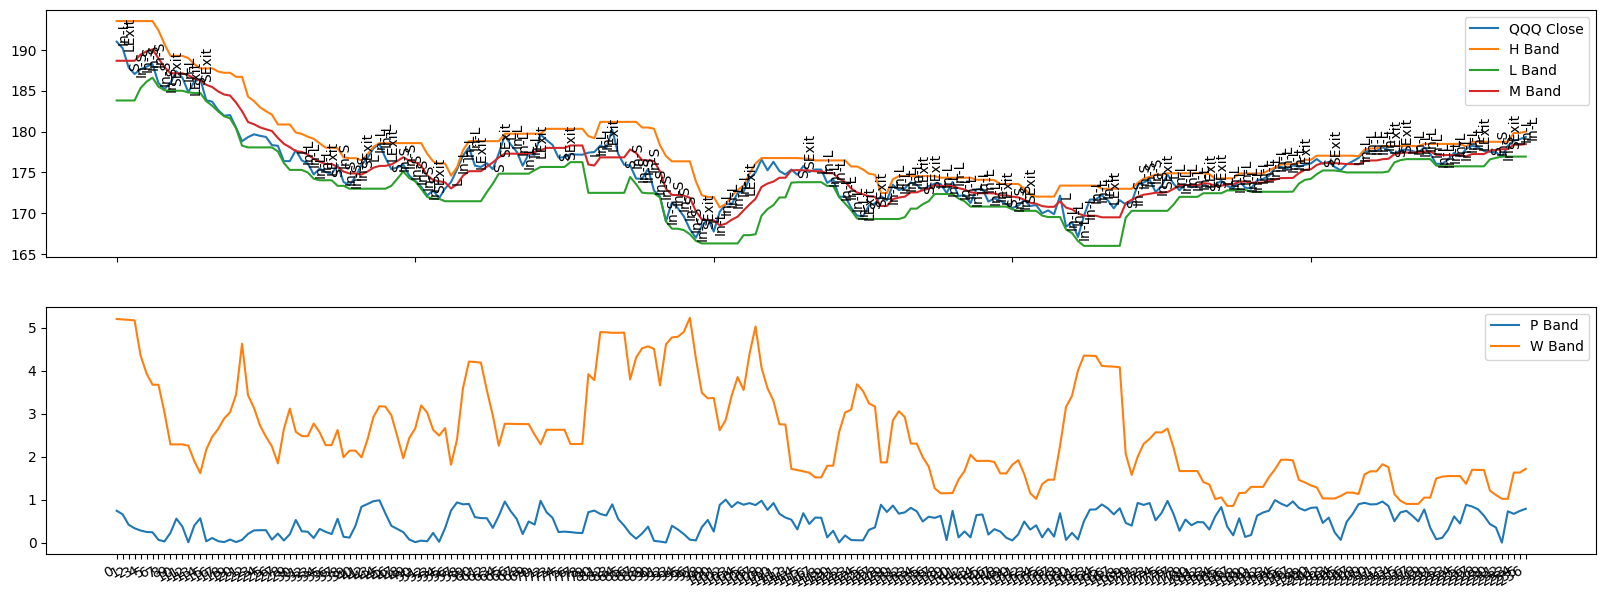

In [10]:
temp = df.loc[as_of_date:]
fig, axes = plt.subplots(2,1,figsize=(20,8))
axes[0].plot(range(len(temp)), temp.close.values, label = "QQQ Close")
axes[0].plot(range(len(temp)), temp[ 'dc_hband'], label = "H Band")
axes[0].plot(range(len(temp)), temp[ 'dc_lband'], label = "L Band")
axes[0].plot(range(len(temp)), temp[ 'dc_mband'], label = "M Band")
axes[1].plot(range(len(temp)), temp[ 'dc_pband'], label = "P Band")
axes[1].plot(range(len(temp)), temp[ 'dc_wband'], label = "W Band")
# axes[1].plot(range(len(temp)), temp[ 'AVG_P'], label = "uP Band")
# axes[1].plot(range(len(temp)), temp[ 'AVG_W'], label = "uW Band")
axes[1].set_xticks(range(len(temp)))
# axes[1].set_xticklabels(temp.index)

#Add the text
text_column = df.columns.tolist().index("Trade")
for i in range(len(temp)):
    axes[0].text(i, temp.iat[i, 3], temp.iat[i, text_column], rotation = 90)
    
fig.autofmt_xdate() # automatically formats the x-axis labels
axes[0].legend()
axes[1].legend()
plt.show()

<Axes: title={'center': 'Cumulative PnL'}, xlabel='timestamp'>

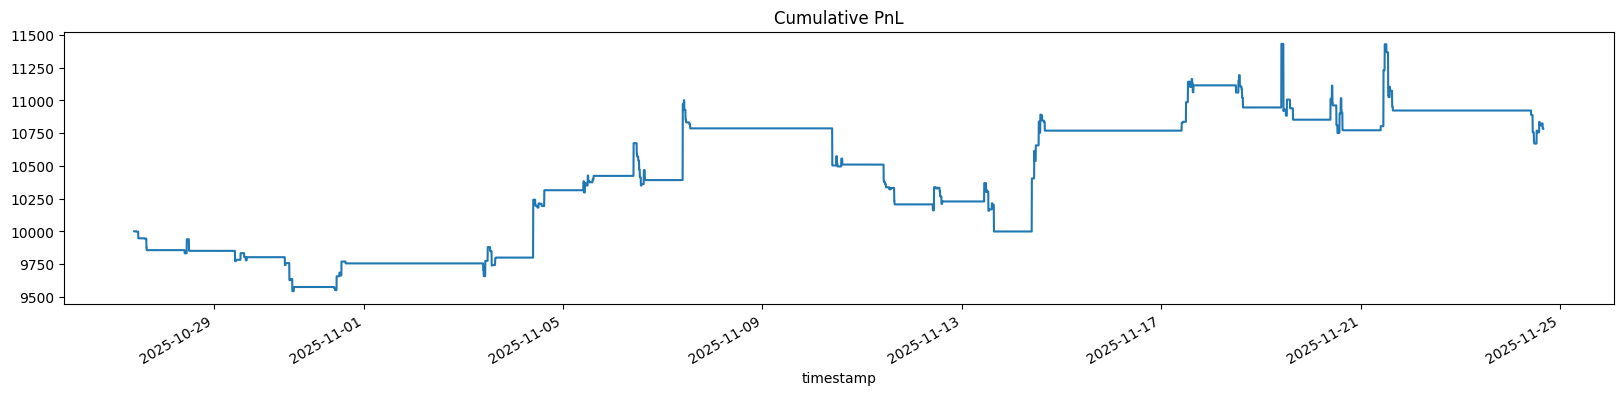

In [11]:
df['CumuPnL'].plot(figsize = (20,4), title="Cumulative PnL")

In [12]:
cum_ret = (df['CumuPnL'].pct_change() + 1).cumprod()
last_peak_return = cum_ret[cum_ret.values == cum_ret.max()].index[-1]
peak = cum_ret.max()
trough = cum_ret.loc[last_peak_return:].min()
max_dd = (trough-peak)/peak

metrics = {
    "Total PnL" : f"{df['PnL'].sum():,.1f}",
    "Wins": df[df['PnL'] > 0].shape[0],
    "Losses": df[df['PnL'] < 0].shape[0],
    "Wins PnL": f"{df[df['PnL'] > 0]['PnL'].sum() : ,.1f}",
    "Losses PnL": f"{df[df['PnL'] < 0]['PnL'].sum() : ,.1f}",
    "Win Ratio": f"{df[df['PnL'] > 0].shape[0] / df['Trade'].value_counts()[['LExit','SExit']].sum() : .1%}",
    "Total Trades": df['Trade'].value_counts()[['LExit','SExit']].sum(),
    "Average PnL" : f"{df['PnL'].sum()/df['Trade'].value_counts()[['LExit','SExit']].sum() : ,.1f}",
    "Max Drawdown": f"{max_dd : .1%}",
    "Annualized Mean Return": f"{df['CumuPnL'].pct_change().mean() * 4 * 24 * 252 : ,.1%}"
}

In [13]:
pd.DataFrame.from_dict(metrics,orient="index").T

,Total PnL,Wins,Losses,Wins PnL,Losses PnL,Win Ratio,Total Trades,Average PnL,Max Drawdown,Annualized Mean Return
0,783.0,67,108,"6,914.6","-6,131.5",38.5%,174,4.5,-6.7%,126.4%


In [8]:
def donchain4(window, temp_df):
    df = temp_df.copy()
    donchain = DonchianChannel(high = df.high, low = df.low, close = df.close, window=window)
    df['dc_hband'] = donchain.donchian_channel_hband()
    df['dc_lband'] = donchain.donchian_channel_lband()
    df['dc_mband'] = donchain.donchian_channel_mband()
    df['dc_pband'] = donchain.donchian_channel_pband()
    df['dc_wband'] = donchain.donchian_channel_wband()
    short = False
    long = False
    enter_price = 0
    df['Trade'] = ""
    df['PnL'] = 0.0
    df['AVG_P'] = 0.0
    df['AVG_W'] = 0.0
    counter = 1
    shares_traded = 0
    notional = 10000
    was_in_short = False
    was_in_long = False
    exit_signal = None
    in_trade_counter=0
    for row in df.itertuples(index=True):
        if counter > window:        
            if short == False and long == False:            
                if was_in_short == False and row.dc_pband <= .5 and row.close < row.dc_mband and row.dc_wband > 0.8:
                    enter_price = row.close
                    shares_traded = round(notional/row.close, 0)
                    short = True
                    df.at[row.Index, 'Trade'] = "S"
                elif was_in_long == False and row.dc_pband >= .5 and row.close > row.dc_mband and row.dc_wband > 0.8:
                    enter_price = row.close
                    shares_traded = round(notional/row.close, 0)
                    long = True
                    df.at[row.Index, 'Trade'] = "L"
                else:
                    pass
            else:
                if short:
                    if ( shares_traded*(enter_price - row.close) / notional ) < -0.05: #Close Position Risk Management  
                        df.at[row.Index, 'PnL'] = shares_traded*(enter_price - row.close)          
                        df.at[row.Index, 'Trade'] = "SExitR"
                        short = False
                        shares_traded = 0
                        was_in_short = True
                        was_in_long = False
                    elif row.dc_pband <= last_dc_pband or row.dc_wband >= last_dc_wband or row.close - row.dc_lband < row.dc_mband - row.close:
                        df.at[row.Index, 'Trade'] = "In-S" #Just mark we are in short position
                        exit_signal = True
                    else:                    
                        df.at[row.Index, 'Trade'] = "In-S" #Just mark we are in short position
                                
                    if exit_signal == True:
                        if row.dc_pband > last_dc_pband and row.dc_wband < last_dc_wband:
                            df.at[row.Index, 'PnL'] = shares_traded*(enter_price - row.close) #Short PnL                    
                            df.at[row.Index, 'Trade'] = "SExit"
                            short = False
                            shares_traded = 0
                            was_in_short = True
                            was_in_long = False
                            exit_signal = False
                elif long:
                    if ( shares_traded*(row.close - enter_price) / notional ) < -0.05: #Close Position Risk Management  
                        df.at[row.Index, 'PnL'] = shares_traded*(row.close - enter_price)               
                        df.at[row.Index, 'Trade'] = "LExitR"
                        long = False
                        shares_traded = 0
                        was_in_long = True
                        was_in_short = False
                    elif row.dc_pband >= last_dc_pband or row.dc_wband >= last_dc_wband or row.dc_hband - row.close < row.close - row.dc_mband:
                        df.at[row.Index, 'Trade'] = "In-L"
                        exit_signal = True
                    else:
                        df.at[row.Index, 'Trade'] = "In-L"
    
                    if exit_signal == True:
                        if row.dc_pband < last_dc_pband and row.dc_wband < last_dc_wband:
                            df.at[row.Index, 'PnL'] = shares_traded*(row.close - enter_price) #Long PnL
                            df.at[row.Index, 'Trade'] = "LExit"
                            long = False
                            shares_traded = 0
                            was_in_long = True
                            was_in_short = False
                else:
                    pass        
        
        #Store this iteration's wide band for next
        last_dc_wband = row.dc_wband
        last_dc_pband = row.dc_pband
        counter +=1 #increment
        
    
    df['CumuPnL'] = df['PnL']
    df.loc[df.index[0], 'CumuPnL'] = 10000 #Initial investment
    df['CumuPnL'] = df['CumuPnL'].cumsum()
    return df